# Startup Success Prediction - Improved Binary Classification Pipeline

In [2]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
DATA_PATH = Path("startup_success_dataset.csv")
TARGET_COLUMN = "target_binary"
POSITIVE_CLASS = 1
CORRELATION_THRESHOLD = 0.70


## 1. Load Dataset


In [ ]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
for column in df.columns:
    print("-", column)

display(df.head())
df.info()


Dataset shape: (100000, 11)

Columns:
- funding_rounds
- founder_experience_years
- team_size
- market_size_billion
- product_traction_users
- burn_rate_million
- revenue_million
- investor_type
- sector
- founder_background
- outcome


,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome
0,4,13,58,48.2255,594843,18.5192,"1,483,962.4463",tier2_vc,Health,academic,IPO
1,1,6,221,31.5326,393020,14.2981,"862,056.8206",tier2_vc,Fintech,first_time,Failure
2,3,5,247,4.9697,27636,20.4476,"97,261.6860",none,SaaS,first_time,Failure
3,3,14,229,3.0842,235376,8.1774,"1,145,785.4380",none,Ecommerce,ex_bigtech,Acquisition
4,1,17,235,13.8182,391765,4.8798,"860,894.9419",none,Health,first_time,Acquisition


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   funding_rounds            100000 non-null  int64  
 1   founder_experience_years  100000 non-null  int64  
 2   team_size                 100000 non-null  int64  
 3   market_size_billion       100000 non-null  float64
 4   product_traction_users    100000 non-null  int64  
 5   burn_rate_million         100000 non-null  float64
 6   revenue_million           100000 non-null  float64
 7   investor_type             100000 non-null  object 
 8   sector                    100000 non-null  object 
 9   founder_background        100000 non-null  object 
 10  outcome                   100000 non-null  object 
dtypes: float64(3), int64(4), object(4)
memory usage: 8.4+ MB


## 2. Target Transformation

The original target is converted to a binary target:

- `Success` = `Acquisition` or `IPO`
- `Failure` = `Failure`


,target,count,pct
0,Failure,55610,55.6100
1,Success,44390,44.3900


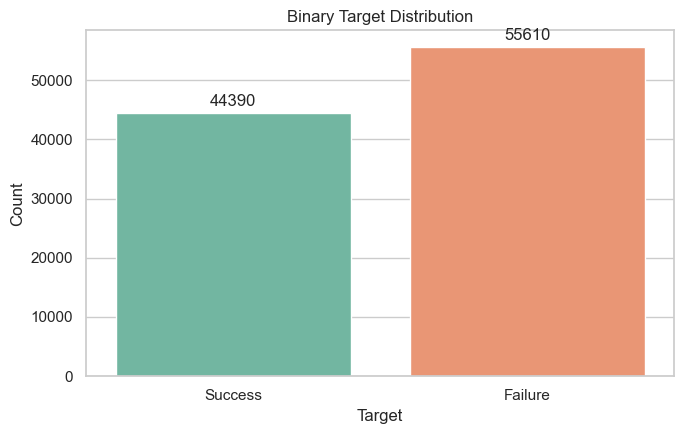

In [ ]:
df["target_binary_label"] = np.where(
    df["outcome"].isin(["Acquisition", "IPO"]),
    "Success",
    "Failure",
)
df["target_binary"] = df["target_binary_label"].map({"Failure": 0, "Success": 1})

target_table = (
    df["target_binary_label"]
    .value_counts()
    .rename_axis("target")
    .reset_index(name="count")
)
target_table["pct"] = (target_table["count"] / len(df) * 100).round(2)
display(target_table)

plt.figure(figsize=(7, 4.5))
ax = sns.countplot(data=df, x="target_binary_label", palette="Set2")
ax.set_title("Binary Target Distribution")
ax.set_xlabel("Target")
ax.set_ylabel("Count")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)
plt.tight_layout()
plt.show()


## 3. Data Quality Check

We inspect missing values, duplicates, and the available signal before modeling.


In [ ]:
quality_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique_values": df.nunique(),
    }
).sort_values(["missing_values", "unique_values"], ascending=[False, False])

duplicate_rows = df.duplicated().sum()

display(quality_summary)
print(f"Duplicate rows: {duplicate_rows}")


,dtype,missing_values,missing_pct,unique_values
market_size_billion,float64,0,0.0000,100000
burn_rate_million,float64,0,0.0000,100000
revenue_million,float64,0,0.0000,100000
product_traction_users,int64,0,0.0000,91579
team_size,int64,0,0.0000,298
founder_experience_years,int64,0,0.0000,25
funding_rounds,int64,0,0.0000,9
sector,object,0,0.0000,7
investor_type,object,0,0.0000,4
founder_background,object,0,0.0000,4


Duplicate rows: 0


## 4. Safe Feature Engineering

Requested engineered features:

- `funding_per_round = funding_total / funding_rounds`
- `experience_per_round = founder_experience_years / funding_rounds`
- `traction_per_employee = product_traction_users / team_size`
- `burn_to_revenue_ratio = burn_rate_million / revenue_million`

Important note:

- raw `revenue_million` will be removed from the final feature set,
- the ratio is kept because it captures operating efficiency,
- if revenue is known to be measured after the prediction window in a real deployment setting, the ratio should also be removed.


In [ ]:
def first_existing_column(columns, candidates):
    for candidate in candidates:
        if candidate in columns:
            return candidate
    return None


def engineer_features(frame: pd.DataFrame):
    engineered = frame.copy()
    created_features = []
    skipped_features = []
    epsilon = 1e-6

    funding_total_col = first_existing_column(
        engineered.columns,
        ["funding_total", "funding_total_usd", "total_funding", "total_funding_usd"],
    )

    if funding_total_col and "funding_rounds" in engineered.columns:
        engineered["funding_per_round"] = (
            pd.to_numeric(engineered[funding_total_col], errors="coerce")
            / engineered["funding_rounds"].clip(lower=1)
        )
        created_features.append("funding_per_round")
    else:
        skipped_features.append("funding_per_round (source column `funding_total` not available)")

    if {"founder_experience_years", "funding_rounds"}.issubset(engineered.columns):
        engineered["experience_per_round"] = (
            engineered["founder_experience_years"]
            / engineered["funding_rounds"].clip(lower=1)
        )
        created_features.append("experience_per_round")

    if {"product_traction_users", "team_size"}.issubset(engineered.columns):
        engineered["traction_per_employee"] = (
            engineered["product_traction_users"]
            / engineered["team_size"].clip(lower=1)
        )
        created_features.append("traction_per_employee")

    if {"burn_rate_million", "revenue_million"}.issubset(engineered.columns):
        engineered["burn_to_revenue_ratio"] = (
            engineered["burn_rate_million"]
            / (engineered["revenue_million"] + epsilon)
        )
        engineered["burn_to_revenue_ratio"] = engineered["burn_to_revenue_ratio"].replace(
            [np.inf, -np.inf],
            np.nan,
        )
        created_features.append("burn_to_revenue_ratio")
    else:
        skipped_features.append("burn_to_revenue_ratio (requires `revenue_million`)")

    return engineered, created_features, skipped_features


engineered_df, created_features, skipped_features = engineer_features(df)

print("Created features:")
print(created_features)
print("\nSkipped requested features:")
print(skipped_features if skipped_features else "None")

display(engineered_df.head())


Created features:
['experience_per_round', 'traction_per_employee', 'burn_to_revenue_ratio']

Skipped requested features:
['funding_per_round (source column `funding_total` not available)']


,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,revenue_million,investor_type,sector,founder_background,outcome,target_binary_label,target_binary,experience_per_round,traction_per_employee,burn_to_revenue_ratio
0,4,13,58,48.2255,594843,18.5192,"1,483,962.4463",tier2_vc,Health,academic,IPO,Success,1,3.2500,"10,255.9138",0.0000
1,1,6,221,31.5326,393020,14.2981,"862,056.8206",tier2_vc,Fintech,first_time,Failure,Failure,0,6.0000,"1,778.3710",0.0000
2,3,5,247,4.9697,27636,20.4476,"97,261.6860",none,SaaS,first_time,Failure,Failure,0,1.6667,111.8866,0.0002
3,3,14,229,3.0842,235376,8.1774,"1,145,785.4380",none,Ecommerce,ex_bigtech,Acquisition,Success,1,4.6667,"1,027.8428",0.0000
4,1,17,235,13.8182,391765,4.8798,"860,894.9419",none,Health,first_time,Acquisition,Success,1,17.0000,"1,667.0851",0.0000


## 5. Data Cleaning and Leakage Control

Cleaning rules:

- remove identifier-like columns if present,
- remove raw `revenue_million`,
- keep the new binary target,
- leave the original multiclass `outcome` column only for reference, then exclude it from modeling.


In [ ]:
model_df = engineered_df.copy()

identifier_patterns = ("id", "uuid", "name", "permalink", "url")
id_columns = [
    col for col in model_df.columns
    if col not in {"outcome", "target_binary", "target_binary_label"}
    and any(pattern in col.lower() for pattern in identifier_patterns)
]

explicit_drop_columns = [col for col in ["revenue_million"] if col in model_df.columns]
drop_columns = sorted(set(id_columns + explicit_drop_columns))

model_df = model_df.drop(columns=drop_columns, errors="ignore")
model_df = model_df.drop_duplicates().copy()

print("Identifier columns removed:", id_columns if id_columns else "None")
print("Explicitly removed risky columns:", explicit_drop_columns if explicit_drop_columns else "None")
print("Shape after cleaning:", model_df.shape)

display(model_df.head())


Identifier columns removed: None
Explicitly removed risky columns: ['revenue_million']
Shape after cleaning: (100000, 15)


,funding_rounds,founder_experience_years,team_size,market_size_billion,product_traction_users,burn_rate_million,investor_type,sector,founder_background,outcome,target_binary_label,target_binary,experience_per_round,traction_per_employee,burn_to_revenue_ratio
0,4,13,58,48.2255,594843,18.5192,tier2_vc,Health,academic,IPO,Success,1,3.2500,"10,255.9138",0.0000
1,1,6,221,31.5326,393020,14.2981,tier2_vc,Fintech,first_time,Failure,Failure,0,6.0000,"1,778.3710",0.0000
2,3,5,247,4.9697,27636,20.4476,none,SaaS,first_time,Failure,Failure,0,1.6667,111.8866,0.0002
3,3,14,229,3.0842,235376,8.1774,none,Ecommerce,ex_bigtech,Acquisition,Success,1,4.6667,"1,027.8428",0.0000
4,1,17,235,13.8182,391765,4.8798,none,Health,first_time,Acquisition,Success,1,17.0000,"1,667.0851",0.0000


## 6. Train-Test Split

We split the data with stratification so the success/failure ratio stays consistent in both sets.


In [ ]:
X = model_df.drop(columns=["outcome", "target_binary", "target_binary_label"], errors="ignore")
y = model_df["target_binary"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Success rate in training set:", round(y_train.mean(), 4))
print("Success rate in test set:", round(y_test.mean(), 4))


X_train shape: (80000, 12)
X_test shape: (20000, 12)
Success rate in training set: 0.4439
Success rate in test set: 0.4439


## 7. Correlation Filtering

Highly correlated numerical features can create redundancy. We detect correlations on the **training set only** and drop features with absolute correlation above `0.70`.


,feature_1,feature_2,correlation
0,founder_experience_years,experience_per_round,0.7180


Features removed due to high correlation: ['experience_per_round']


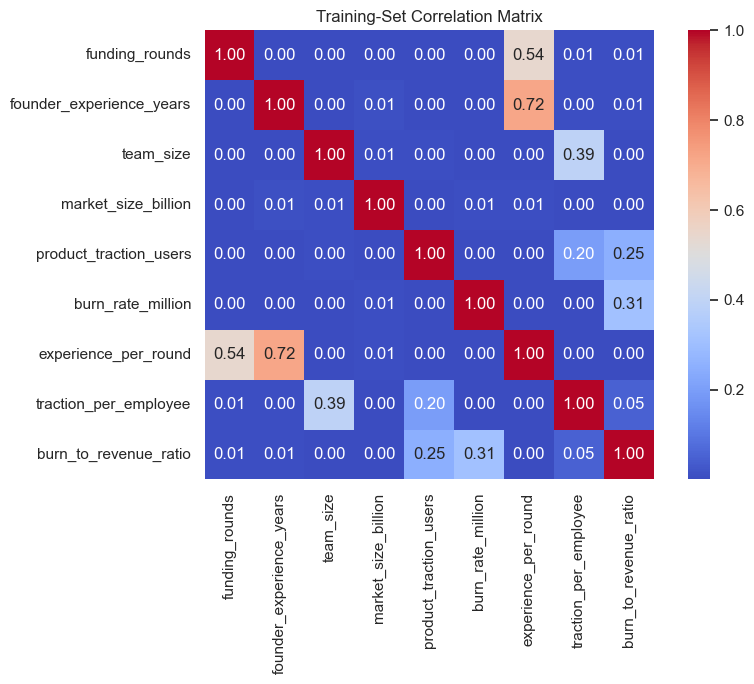

Shape after correlation filtering: (80000, 11) (20000, 11)


In [ ]:
def find_high_correlation_features(frame: pd.DataFrame, threshold: float = 0.70):
    numeric_frame = frame.select_dtypes(include=["number"]).copy()
    correlation_matrix = numeric_frame.corr().abs()
    upper_triangle = correlation_matrix.where(
        np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
    )

    correlated_pairs = []
    for column in upper_triangle.columns:
        for row_name in upper_triangle.index[upper_triangle[column] > threshold]:
            correlated_pairs.append(
                {
                    "feature_1": row_name,
                    "feature_2": column,
                    "correlation": upper_triangle.loc[row_name, column],
                }
            )

    features_to_drop = [
        column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)
    ]

    if correlated_pairs:
        pairs_df = pd.DataFrame(correlated_pairs).sort_values("correlation", ascending=False)
    else:
        pairs_df = pd.DataFrame(columns=["feature_1", "feature_2", "correlation"])
    return correlation_matrix, pairs_df, features_to_drop


train_corr_matrix, correlated_pairs_df, high_corr_features = find_high_correlation_features(
    X_train,
    threshold=CORRELATION_THRESHOLD,
)

if correlated_pairs_df.empty:
    print("No numerical feature pairs exceeded the correlation threshold.")
else:
    display(correlated_pairs_df)

print("Features removed due to high correlation:", high_corr_features if high_corr_features else "None")

plt.figure(figsize=(9, 7))
sns.heatmap(train_corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Training-Set Correlation Matrix")
plt.tight_layout()
plt.show()

X_train_filtered = X_train.drop(columns=high_corr_features, errors="ignore")
X_test_filtered = X_test.drop(columns=high_corr_features, errors="ignore")

print("Shape after correlation filtering:", X_train_filtered.shape, X_test_filtered.shape)


## 8. Preprocessing and Feature Selection

The preprocessing pipeline:

- imputes missing values,
- one-hot encodes categorical features,
- scales numerical features,
- keeps only important transformed features with `SelectFromModel(RandomForestClassifier)`.


In [ ]:
numerical_features = X_train_filtered.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train_filtered.select_dtypes(exclude=["number"]).columns.tolist()

def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", make_one_hot_encoder()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced_subsample",
        n_jobs=-1,
    ),
    threshold="median",
)

def build_pipeline(model, use_selector=True):
    steps = [("preprocessor", clone(preprocessor))]
    if use_selector:
        steps.append(("selector", clone(selector)))
    steps.append(("model", clone(model)))
    return Pipeline(steps=steps)


In [ ]:
feature_selector_pipeline = Pipeline(
    steps=[
        ("preprocessor", clone(preprocessor)),
        ("selector", clone(selector)),
    ]
)

feature_selector_pipeline.fit(X_train_filtered, y_train)
transformed_feature_names = feature_selector_pipeline.named_steps["preprocessor"].get_feature_names_out()
selection_mask = feature_selector_pipeline.named_steps["selector"].get_support()
selected_feature_names = transformed_feature_names[selection_mask]

feature_selection_df = pd.DataFrame(
    {
        "feature": transformed_feature_names,
        "selected": selection_mask,
    }
).sort_values(["selected", "feature"], ascending=[False, True])

print(f"Selected transformed features: {selection_mask.sum()} / {len(selection_mask)}")
display(feature_selection_df)


Selected transformed features: 12 / 23


,feature,selected
20,cat__founder_background_ex_bigtech,True
21,cat__founder_background_first_time,True
8,cat__investor_type_angel,True
11,cat__investor_type_tier2_vc,True
5,num__burn_rate_million,True
7,num__burn_to_revenue_ratio,True
1,num__founder_experience_years,True
0,num__funding_rounds,True
3,num__market_size_billion,True
4,num__product_traction_users,True


## 9. Baseline Model

Before training advanced models, we establish a baseline using the majority class.


In [ ]:
def compute_binary_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label=POSITIVE_CLASS, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=POSITIVE_CLASS, zero_division=0),
        "F1": f1_score(y_true, y_pred, pos_label=POSITIVE_CLASS, zero_division=0),
    }


baseline_pipeline = build_pipeline(DummyClassifier(strategy="most_frequent"), use_selector=False)
baseline_pipeline.fit(X_train_filtered, y_train)
baseline_predictions = baseline_pipeline.predict(X_test_filtered)
baseline_metrics = compute_binary_metrics(y_test, baseline_predictions)

baseline_df = pd.DataFrame([{"Model": "Baseline (Majority Class)", **baseline_metrics}])
display(baseline_df.style.format({col: "{:.4f}" for col in baseline_df.columns if col != "Model"}))


,Model,Accuracy,Precision,Recall,F1
0,Baseline (Majority Class),0.5561,0.0000,0.0000,0.0000


## 10. Candidate Models

We train the requested models:

- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost

Class imbalance is handled through `class_weight` where available, or an equivalent weighted configuration for the algorithm.


In [ ]:
success_count = int((y_train == 1).sum())
failure_count = int((y_train == 0).sum())
scale_pos_weight = failure_count / max(success_count, 1)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        n_estimators=200,
        learning_rate=0.05,
        subsample=0.90,
    ),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=250,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.90,
        colsample_bytree=0.90,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1,
    )
else:
    print("XGBoost is not installed. Uncomment the installation cell to include it.")


def get_fit_params(model_name, y_values):
    if model_name == "Gradient Boosting":
        return {
            "model__sample_weight": compute_sample_weight(
                class_weight="balanced",
                y=y_values,
            )
        }
    return {}


def cross_validated_f1(model_name, estimator, X_data, y_data, cv):
    fold_scores = []
    for train_idx, valid_idx in cv.split(X_data, y_data):
        X_fold_train = X_data.iloc[train_idx].copy()
        X_fold_valid = X_data.iloc[valid_idx].copy()
        y_fold_train = y_data.iloc[train_idx].copy()
        y_fold_valid = y_data.iloc[valid_idx].copy()

        pipeline = build_pipeline(estimator, use_selector=True)
        fit_params = get_fit_params(model_name, y_fold_train)
        pipeline.fit(X_fold_train, y_fold_train, **fit_params)
        fold_predictions = pipeline.predict(X_fold_valid)
        fold_scores.append(
            f1_score(
                y_fold_valid,
                fold_predictions,
                pos_label=POSITIVE_CLASS,
                zero_division=0,
            )
        )
    return np.array(fold_scores)


## 11. Base Model Evaluation

Model ranking is driven by **cross-validated F1-score** on the training data. Holdout test metrics are reported separately for transparency.


In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

evaluation_rows = []
reports = {}
fitted_pipelines = {}
test_predictions = {}

for model_name, estimator in models.items():
    cv_scores = cross_validated_f1(model_name, estimator, X_train_filtered, y_train, cv)

    pipeline = build_pipeline(estimator, use_selector=True)
    fit_params = get_fit_params(model_name, y_train)
    pipeline.fit(X_train_filtered, y_train, **fit_params)
    preds = pipeline.predict(X_test_filtered)

    fitted_pipelines[model_name] = pipeline
    test_predictions[model_name] = preds
    reports[model_name] = classification_report(
        y_test,
        preds,
        target_names=["Failure", "Success"],
        zero_division=0,
    )

    metrics_row = compute_binary_metrics(y_test, preds)
    metrics_row.update(
        {
            "Model": model_name,
            "CV F1 Mean": cv_scores.mean(),
            "CV F1 Std": cv_scores.std(),
        }
    )
    evaluation_rows.append(metrics_row)

comparison_df = pd.DataFrame(evaluation_rows).sort_values(
    by=["CV F1 Mean", "F1", "Recall", "Precision"],
    ascending=False,
).reset_index(drop=True)

display(
    comparison_df[
        ["Model", "CV F1 Mean", "CV F1 Std", "Accuracy", "Precision", "Recall", "F1"]
    ].style.format(
        {
            col: "{:.4f}"
            for col in ["CV F1 Mean", "CV F1 Std", "Accuracy", "Precision", "Recall", "F1"]
        }
    )
)


,Model,CV F1 Mean,CV F1 Std,Accuracy,Precision,Recall,F1
0,XGBoost,0.7278,0.0020,0.7593,0.7214,0.7457,0.7334
1,Gradient Boosting,0.7269,0.0022,0.7563,0.7143,0.7516,0.7325
2,Random Forest,0.7140,0.0018,0.7550,0.7321,0.7065,0.7191
3,Logistic Regression,0.7113,0.0010,0.7398,0.6974,0.7308,0.7137


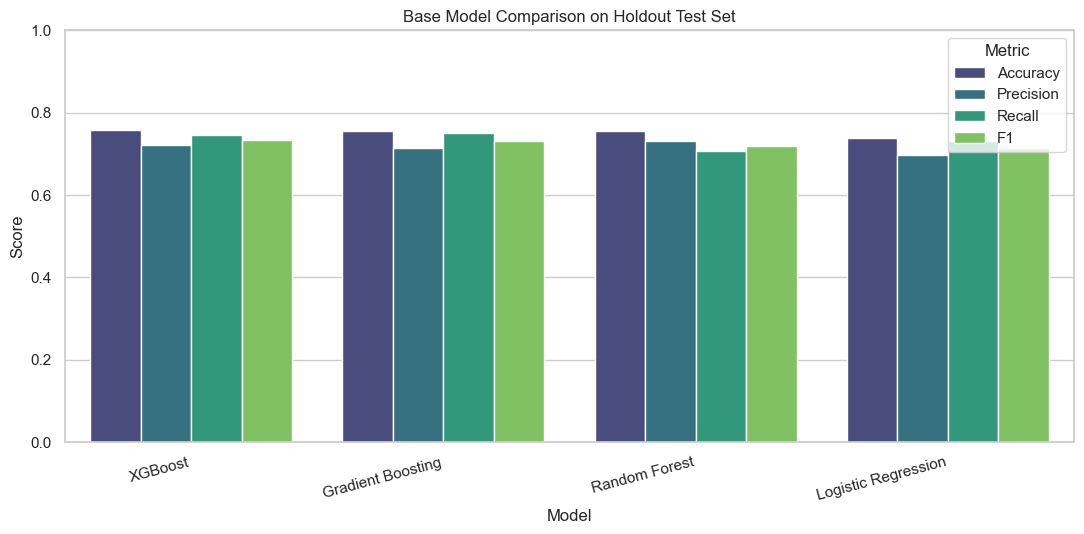

In [ ]:
plot_df = comparison_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(11, 5.5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", palette="viridis")
plt.title("Base Model Comparison on Holdout Test Set")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


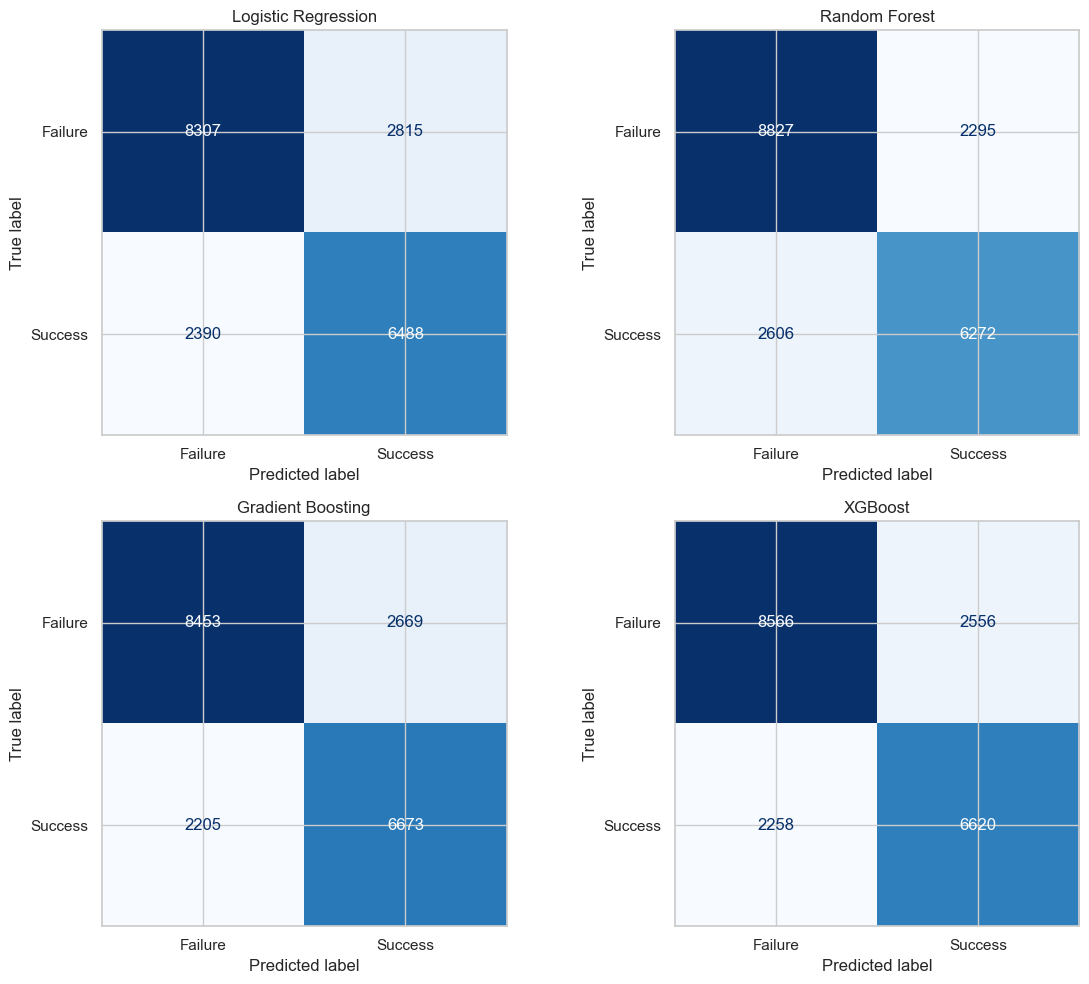

In [ ]:
n_models = len(test_predictions)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (model_name, preds) in zip(axes, test_predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        preds,
        display_labels=["Failure", "Success"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(model_name)

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
for model_name in comparison_df["Model"]:
    print("=" * 100)
    print(model_name)
    print("=" * 100)
    print(reports[model_name])


XGBoost
              precision    recall  f1-score   support

     Failure       0.79      0.77      0.78     11122
     Success       0.72      0.75      0.73      8878

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000

Gradient Boosting
              precision    recall  f1-score   support

     Failure       0.79      0.76      0.78     11122
     Success       0.71      0.75      0.73      8878

    accuracy                           0.76     20000
   macro avg       0.75      0.76      0.75     20000
weighted avg       0.76      0.76      0.76     20000

Random Forest
              precision    recall  f1-score   support

     Failure       0.77      0.79      0.78     11122
     Success       0.73      0.71      0.72      8878

    accuracy                           0.75     20000
   macro avg       0.75      0.75      0.75     20000
weighted avg       0.75      0.75 

## 12. Hyperparameter Tuning

The best candidate is selected using cross-validated F1-score, then tuned with `RandomizedSearchCV`.


In [ ]:
best_model_name = comparison_df.loc[0, "Model"]
best_estimator = models[best_model_name]

search_spaces = {
    "Logistic Regression": {
        "model__C": np.logspace(-3, 2, 12),
        "model__solver": ["liblinear", "lbfgs"],
    },
    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 6, 10, 14],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": ["sqrt", "log2", None],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 150, 200, 300],
        "model__learning_rate": [0.03, 0.05, 0.08, 0.10],
        "model__max_depth": [2, 3, 4],
        "model__subsample": [0.8, 0.9, 1.0],
        "model__min_samples_leaf": [1, 3, 5],
    },
    "XGBoost": {
        "model__n_estimators": [150, 250, 350],
        "model__max_depth": [3, 4, 5, 6],
        "model__learning_rate": [0.03, 0.05, 0.08, 0.10],
        "model__subsample": [0.8, 0.9, 1.0],
        "model__colsample_bytree": [0.7, 0.9, 1.0],
        "model__reg_lambda": [1, 5, 10],
    },
}

search = RandomizedSearchCV(
    estimator=build_pipeline(best_estimator, use_selector=True),
    param_distributions=search_spaces[best_model_name],
    n_iter=10,
    scoring="f1",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

search_fit_params = get_fit_params(best_model_name, y_train)
search.fit(X_train_filtered, y_train, **search_fit_params)

tuned_best_pipeline = search.best_estimator_

print("Best model selected for tuning:", best_model_name)
print("Best CV F1 from tuning:", round(search.best_score_, 4))
print("Best parameters:")
print(search.best_params_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best model selected for tuning: XGBoost
Best CV F1 from tuning: 0.7289
Best parameters:
{'model__subsample': 0.8, 'model__reg_lambda': 10, 'model__n_estimators': 250, 'model__max_depth': 3, 'model__learning_rate': 0.08, 'model__colsample_bytree': 1.0}


## 13. Final Model Evaluation

The tuned best model is evaluated on the holdout test set and compared against the baseline.


In [ ]:
tuned_predictions = tuned_best_pipeline.predict(X_test_filtered)

tuned_metrics = compute_binary_metrics(y_test, tuned_predictions)
untuned_best_metrics = comparison_df.loc[comparison_df["Model"] == best_model_name, ["Accuracy", "Precision", "Recall", "F1"]].iloc[0].to_dict()

final_comparison = pd.DataFrame(
    [
        {"Model": "Baseline (Majority Class)", **baseline_metrics},
        {"Model": f"Untuned {best_model_name}", **untuned_best_metrics},
        {"Model": f"Tuned {best_model_name}", **tuned_metrics},
    ]
)

display(final_comparison.style.format({col: "{:.4f}" for col in final_comparison.columns if col != "Model"}))

f1_improvement_vs_baseline = tuned_metrics["F1"] - baseline_metrics["F1"]
accuracy_improvement_vs_baseline = tuned_metrics["Accuracy"] - baseline_metrics["Accuracy"]

print(f"Final tuned model: {best_model_name}")
print(f"Baseline F1-score: {baseline_metrics['F1']:.4f}")
print(f"Final F1-score: {tuned_metrics['F1']:.4f}")
print(f"F1 improvement vs baseline: {f1_improvement_vs_baseline:.4f}")
print(f"Accuracy improvement vs baseline: {accuracy_improvement_vs_baseline:.4f}")


,Model,Accuracy,Precision,Recall,F1
0,Baseline (Majority Class),0.5561,0.0000,0.0000,0.0000
1,Untuned XGBoost,0.7593,0.7214,0.7457,0.7334
2,Tuned XGBoost,0.7596,0.7224,0.7446,0.7333


Final tuned model: XGBoost
Baseline F1-score: 0.0000
Final F1-score: 0.7333
F1 improvement vs baseline: 0.7333
Accuracy improvement vs baseline: 0.2035


In [ ]:
from sklearn.model_selection import learning_curve

# ── Learning Curve on the tuned best pipeline ──────────────────────────
train_sizes, train_scores, val_scores = learning_curve(
    estimator   = tuned_best_pipeline,
    X           = X_train_filtered,
    y           = y_train,
    train_sizes = np.linspace(0.10, 1.0, 10),
    cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring     = "f1",
    n_jobs      = -1,
    shuffle     = True,
    random_state= RANDOM_STATE,
)

# ── Compute mean & std ─────────────────────────────────────────────────
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

# ── Plot ───────────────────────────────────────────────────────────


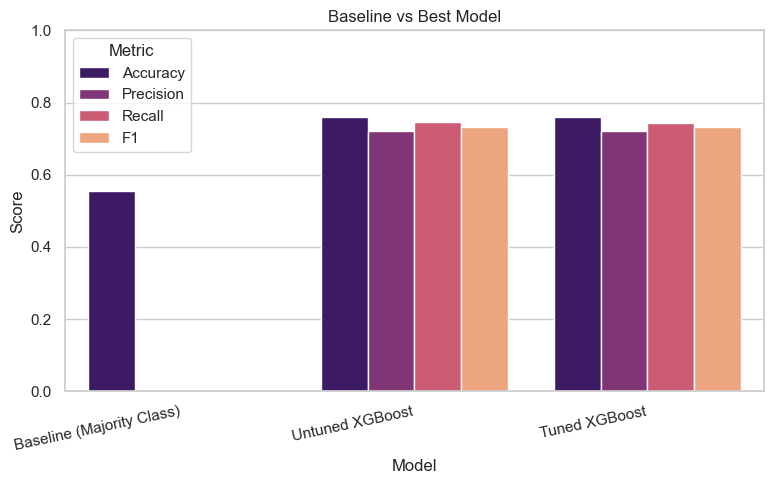

In [ ]:
plt.figure(figsize=(8, 5))
final_plot_df = final_comparison.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1"],
    var_name="Metric",
    value_name="Score",
)
sns.barplot(data=final_plot_df, x="Model", y="Score", hue="Metric", palette="magma")
plt.title("Baseline vs Best Model")
plt.ylim(0, 1)
plt.xticks(rotation=12, ha="right")
plt.tight_layout()
plt.show()


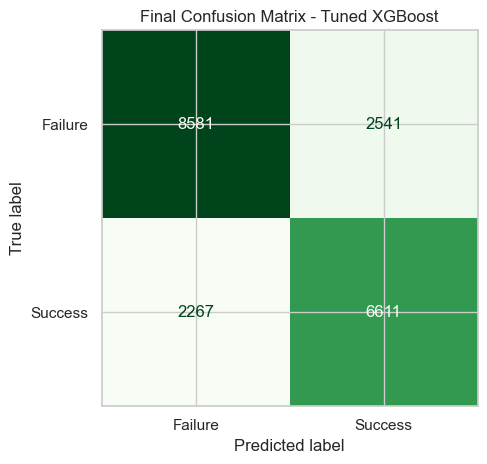

              precision    recall  f1-score   support

     Failure       0.79      0.77      0.78     11122
     Success       0.72      0.74      0.73      8878

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000



In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_predictions,
    display_labels=["Failure", "Success"],
    cmap="Greens",
    colorbar=False,
)
plt.title(f"Final Confusion Matrix - Tuned {best_model_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, tuned_predictions, target_names=["Failure", "Success"], zero_division=0))


## 14. Feature Importance

Feature importance is extracted from the tuned best pipeline after preprocessing and feature selection.


,feature,importance
0,num__product_traction_users,0.4155
1,num__funding_rounds,0.2073
2,num__founder_experience_years,0.1401
3,num__burn_to_revenue_ratio,0.0822
4,num__team_size,0.0577
5,num__burn_rate_million,0.0526
6,num__traction_per_employee,0.0119
7,cat__investor_type_angel,0.0079
8,cat__investor_type_tier2_vc,0.0071
9,cat__founder_background_ex_bigtech,0.0062


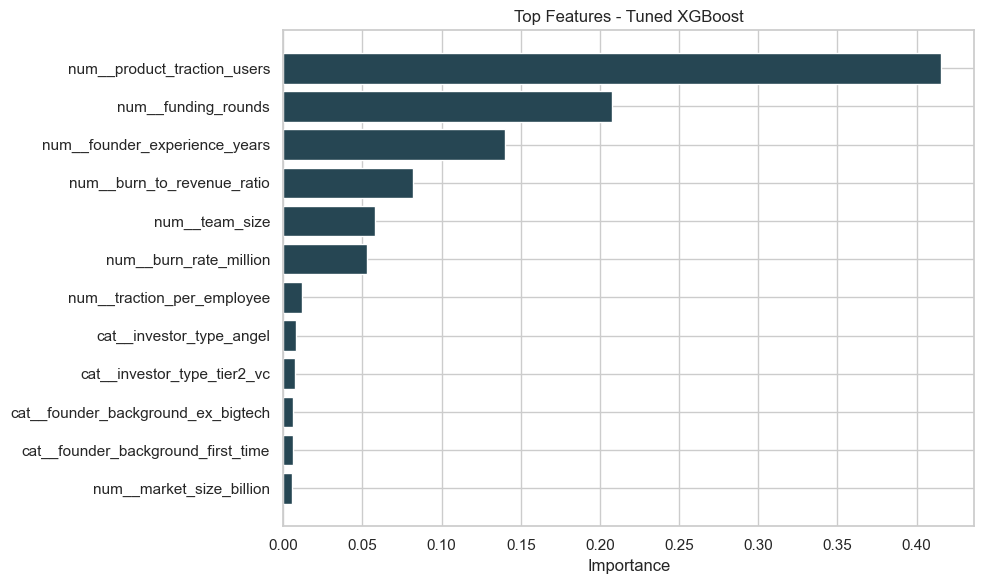

In [ ]:
selected_mask_final = tuned_best_pipeline.named_steps["selector"].get_support()
transformed_names_final = tuned_best_pipeline.named_steps["preprocessor"].get_feature_names_out()
selected_names_final = transformed_names_final[selected_mask_final]
final_model = tuned_best_pipeline.named_steps["model"]

if hasattr(final_model, "feature_importances_"):
    importance_values = final_model.feature_importances_
elif hasattr(final_model, "coef_"):
    importance_values = np.abs(final_model.coef_).ravel()
else:
    importance_values = None

if importance_values is not None:
    importance_df = (
        pd.DataFrame(
            {
                "feature": selected_names_final,
                "importance": importance_values,
            }
        )
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    display(importance_df.head(20))

    plt.figure(figsize=(10, 6))
    top_importance_df = importance_df.head(15).sort_values("importance")
    plt.barh(top_importance_df["feature"], top_importance_df["importance"], color="#264653")
    plt.title(f"Top Features - Tuned {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("The final model does not expose feature importances or coefficients.")


## 15. Save Final Model

Save the final tuned model and useful metadata for deployment.


In [ ]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

model_artifact_path = artifacts_dir / "startup_success_binary_best_model.joblib"

joblib.dump(
    {
        "pipeline": tuned_best_pipeline,
        "best_model_name": best_model_name,
        "target_mapping": {"Failure": 0, "Success": 1},
        "created_features": created_features,
        "skipped_requested_features": skipped_features,
        "removed_id_columns": id_columns,
        "removed_risky_columns": explicit_drop_columns,
        "removed_high_corr_features": high_corr_features,
        "train_columns_after_filtering": list(X_train_filtered.columns),
        "selected_transformed_features": list(selected_names_final),
        "correlation_threshold": CORRELATION_THRESHOLD,
    },
    model_artifact_path,
)

print(f"Model artifact saved to: {model_artifact_path.resolve()}")


Model artifact saved to: C:\Users\XPS\Downloads\modelStarupSuccess\artifacts\startup_success_binary_best_model.joblib


## 16. Conclusion

This improved pipeline converts the startup outcome task into a more practical binary classification problem and applies stronger modeling discipline:

- leakage-aware feature removal,
- class imbalance handling,
- redundancy filtering,
- model-based feature selection,
- cross-validated model selection,
- hyperparameter tuning,
- final artifact export.

The final model should be preferred over the baseline only if it delivers a meaningful gain in F1-score while keeping realistic, non-perfect performance on the holdout set.
